# Free Shipping — Deep Dive

Follow-up to `orders_eda.ipynb`. Working hypothesis from `discovery.txt`: the profit dip for 800-1200g shipments is caused by free shipping. This notebook checks:

1. How much free shipping we actually give out (volume, trend, by weight, by country)
2. Whether free-shipping orders are less profitable than paid-shipping orders
3. Whether free shipping specifically explains the 800-1200g dip, or something else does

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-999, 999)

PLAIN = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
PCT = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}%")


def set_log_axis_plain(ax, axis="x"):
    """Show plain whole numbers (e.g. 1,000) on a log axis instead of 10^n."""
    a = ax.xaxis if axis == "x" else ax.yaxis
    a.set_major_formatter(PLAIN)
    a.set_minor_formatter(mticker.NullFormatter())


df = pd.read_csv("orders.csv", parse_dates=["Order_Date"])
df["free_shipping"] = df["Shipping_fee_excl__VAT"] == 0
df.shape

(682792, 12)

## 1. How much free shipping do we give out?

In [2]:
n_free = df["free_shipping"].sum()
n_paid = (~df["free_shipping"]).sum()
free_rate = df["free_shipping"].mean() * 100

print(f"Free-shipping orders: {n_free:,} ({free_rate:.1f}%)")
print(f"Paid-shipping orders: {n_paid:,} ({100 - free_rate:.1f}%)")

Free-shipping orders: 454,342 (66.5%)
Paid-shipping orders: 228,450 (33.5%)


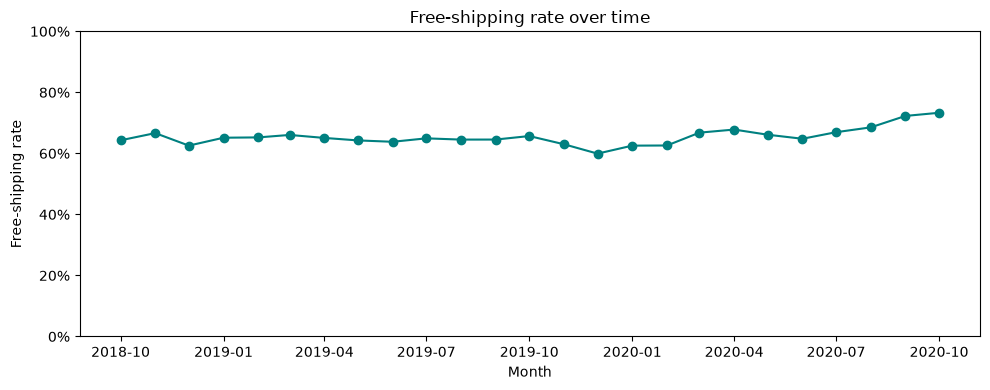

In [3]:
free_rate_by_month = df.set_index("Order_Date")["free_shipping"].resample("MS").mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(free_rate_by_month.index, free_rate_by_month.values, marker="o", color="teal")
ax.set_ylabel("Free-shipping rate")
ax.set_xlabel("Month")
ax.set_title("Free-shipping rate over time")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 100)
fig.tight_layout()
plt.show()

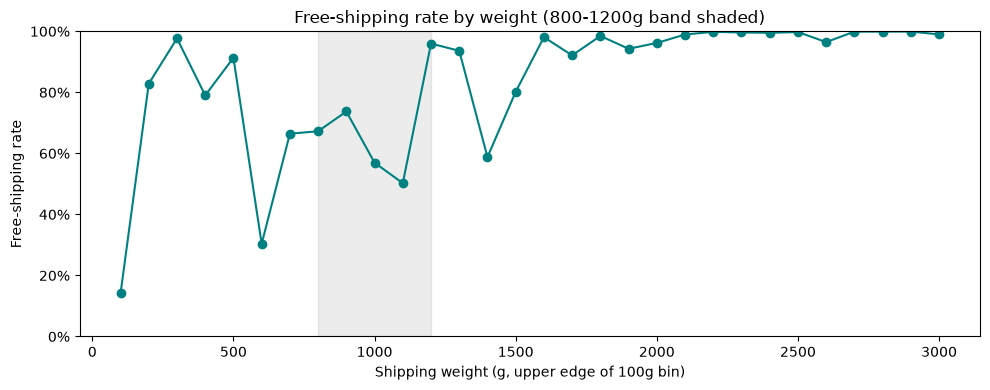

In [4]:
weighted = df.dropna(subset=["Order_weight__g"])
weighted = weighted[weighted["Order_weight__g"] <= 3000]
bins_100g = pd.cut(weighted["Order_weight__g"], bins=range(0, 3100, 100))
free_by_weight = weighted.groupby(bins_100g, observed=True)["free_shipping"].mean() * 100
free_by_weight.index = free_by_weight.index.map(lambda iv: int(iv.right))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(free_by_weight.index, free_by_weight.values, marker="o", color="teal")
ax.axvspan(800, 1200, color="grey", alpha=0.15)
ax.set_ylabel("Free-shipping rate")
ax.set_xlabel("Shipping weight (g, upper edge of 100g bin)")
ax.set_title("Free-shipping rate by weight (800-1200g band shaded)")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 100)
fig.tight_layout()
plt.show()

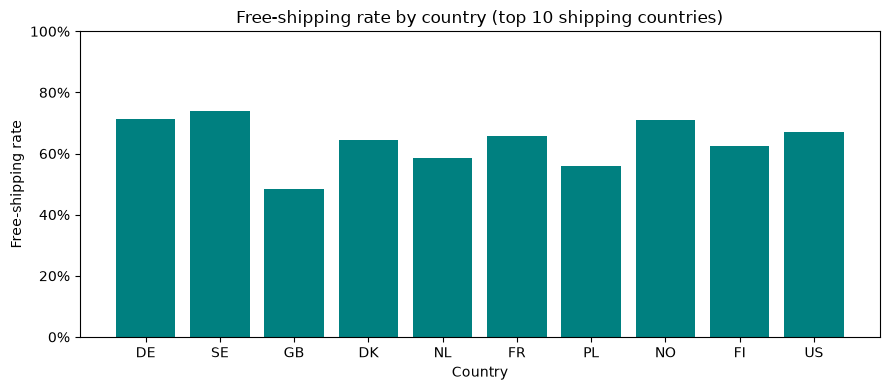

In [5]:
top10_countries = df["Shipping_Country"].value_counts().head(10).index.tolist()
free_by_country = df[df["Shipping_Country"].isin(top10_countries)].groupby("Shipping_Country")["free_shipping"].mean() * 100
free_by_country = free_by_country.reindex(top10_countries)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(free_by_country.index, free_by_country.values, color="teal")
ax.set_ylabel("Free-shipping rate")
ax.set_xlabel("Country")
ax.set_title("Free-shipping rate by country (top 10 shipping countries)")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 100)
fig.tight_layout()
plt.show()

## 2. Are free-shipping orders actually less profitable?

In [6]:
comparison = df.groupby("free_shipping")[["Profit", "Profit_margin", "Total_amount_excl__VAT"]].mean()
comparison.index = comparison.index.map({True: "Free shipping", False: "Paid shipping"})
comparison.columns = ["Avg profit", "Avg profit margin", "Avg order value"]
comparison

,Avg profit,Avg profit margin,Avg order value
free_shipping,,,
Paid shipping,149.800491,0.636308,235.883387
Free shipping,417.356198,0.644891,649.020321


Free-shipping orders are actually **more** profitable on average, not less — nearly 3x the profit of paid-shipping orders, with a slightly *higher* margin. That's the opposite of what "free shipping eats into profit" would predict, so it's worth checking why: is free shipping simply a reward for bigger orders?

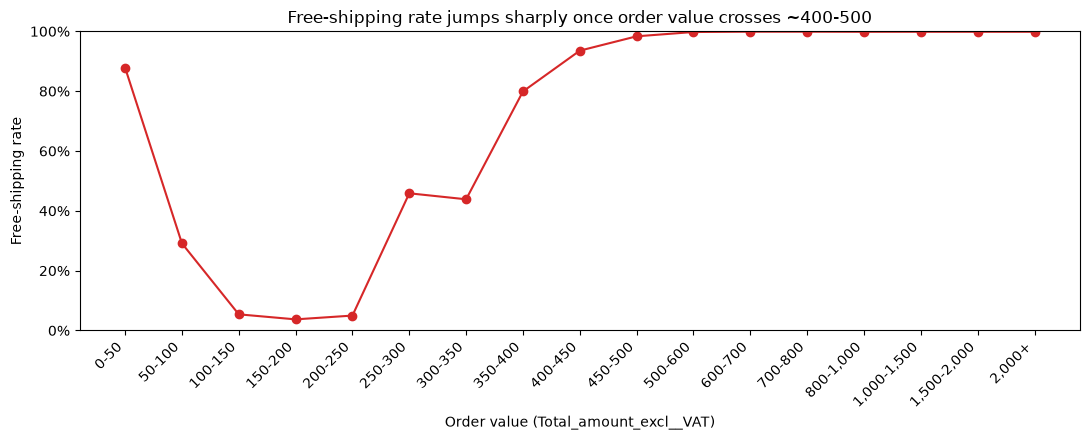

In [7]:
value_bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 600, 700, 800, 1000, 1500, 2000, 999999]
bins = pd.cut(df["Total_amount_excl__VAT"], bins=value_bins)
free_by_value = df.groupby(bins, observed=True)["free_shipping"].mean() * 100
free_by_value.index = [f"{int(iv.left):,}-{int(iv.right):,}" if iv.right < 999999 else f"{int(iv.left):,}+" for iv in free_by_value.index]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(free_by_value.index, free_by_value.values, marker="o", color="tab:red")
ax.set_ylabel("Free-shipping rate")
ax.set_xlabel("Order value (Total_amount_excl__VAT)")
ax.set_title("Free-shipping rate jumps sharply once order value crosses ~400-500")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 100)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.show()

This looks like a standard **spend-threshold free-shipping policy**: the free-shipping rate is low (~1-6%) for mid-range orders (100-250), then climbs steeply from ~250 to ~500, and is essentially universal (~99.8%+) above ~500. (The small bump at the very bottom, 0-50, is a separate small group of cheap/sample items, not the main policy.) So free shipping isn't random — it's granted mainly to bigger baskets, which explains why free-shipping orders are more profitable on average: they're bigger orders, not "loss leaders."

## 3. Does free shipping actually explain the 800-1200g dip?

`discovery.txt` hypothesizes the profit dip in 800-1200g is *caused by* free shipping. Two different mechanisms could produce that dip, and they imply very different fixes:

- **Mix-shift story:** the 800-1200g band simply has a higher *share* of free-shipping orders than other bands, and free-shipping orders are worth less — so more free shipping mechanically drags the average down.
- **Composition story:** the band's free-shipping orders are themselves worth less than free-shipping orders elsewhere (a specific lower-value product happens to live in this band and happens to qualify for free shipping) — free shipping is a side effect, not the cause.

Compare the free-shipping rate and the per-group (free vs. paid) average profit inside the band vs. outside it.

In [8]:
d = df.dropna(subset=["Order_weight__g", "Profit", "Total_amount_excl__VAT"]).copy()
d["band"] = (d["Order_weight__g"] >= 800) & (d["Order_weight__g"] <= 1200)

summary = d.groupby(["band", "free_shipping"]).agg(
    n=("Profit", "size"),
    avg_profit=("Profit", "mean"),
    avg_order_value=("Total_amount_excl__VAT", "mean"),
)
summary.index = summary.index.set_names(["800-1200g band", "free_shipping"])
summary = summary.rename(index={True: "Free", False: "Paid"}, level="free_shipping")
summary = summary.rename(index={True: "Yes", False: "No"}, level="800-1200g band")
summary

n  avg_profit  avg_order_value
800-1200g band free_shipping                                     
No             Paid           183920  148.754586       236.845870
               Free           369413  427.061313       671.971210
Yes            Paid             7330  168.396714       276.620630
               Free            18074  310.397261       491.711561

In [9]:
band = d[d["band"]]
rest = d[~d["band"]]

band_free_rate = band["free_shipping"].mean()
rest_free_rate = rest["free_shipping"].mean()

band_profit_free = band.loc[band["free_shipping"], "Profit"].mean()
band_profit_paid = band.loc[~band["free_shipping"], "Profit"].mean()
rest_profit_free = rest.loc[rest["free_shipping"], "Profit"].mean()
rest_profit_paid = rest.loc[~rest["free_shipping"], "Profit"].mean()

actual_band_avg = band["Profit"].mean()
rest_avg = rest["Profit"].mean()
gap = rest_avg - actual_band_avg

# Keep the band's own free/paid MIX, but swap in "rest"'s per-group profit LEVELS.
# If this recovers most of the gap, the gap is a composition/value effect, not a mix effect.
cf_composition_removed = band_free_rate * rest_profit_free + (1 - band_free_rate) * rest_profit_paid

# Keep the band's own per-group profit LEVELS, but swap in "rest"'s free/paid MIX.
# If this stays close to the band's actual average, mix alone isn't the driver.
cf_mix_removed = rest_free_rate * band_profit_free + (1 - rest_free_rate) * band_profit_paid

print(f"Free-shipping rate — band: {band_free_rate*100:.1f}% | rest: {rest_free_rate*100:.1f}% (+{(band_free_rate-rest_free_rate)*100:.1f}pp)")
print()
print(f"Actual avg profit — band: {actual_band_avg:,.0f} | rest: {rest_avg:,.0f}  (gap: {gap:,.0f})")
print()
print("Scenario 1 — band keeps its own (higher) free-shipping share, but its free/paid orders")
print(f"are worth what free/paid orders are worth elsewhere: avg profit -> {cf_composition_removed:,.0f}")
print(f"  -> recovers {(cf_composition_removed - actual_band_avg) / gap * 100:.0f}% of the gap to 'rest'")
print()
print("Scenario 2 — band gets the SAME free-shipping share as the rest of the data, but keeps")
print(f"its own (lower-value) free/paid orders: avg profit -> {cf_mix_removed:,.0f}")
print(f"  -> recovers only {(cf_mix_removed - actual_band_avg) / gap * 100:.0f}% of the gap to 'rest'")

Free-shipping rate — band: 71.1% | rest: 66.8% (+4.4pp)

Actual avg profit — band: 269 | rest: 335  (gap: 65)

Scenario 1 — band keeps its own (higher) free-shipping share, but its free/paid orders
are worth what free/paid orders are worth elsewhere: avg profit -> 347
  -> recovers 119% of the gap to 'rest'

Scenario 2 — band gets the SAME free-shipping share as the rest of the data, but keeps
its own (lower-value) free/paid orders: avg profit -> 263
  -> recovers only -10% of the gap to 'rest'


## Conclusion

**Free shipping is not eating into our profit.** Free-shipping orders average ~3x the profit of paid-shipping orders and carry a slightly *higher* margin, because free shipping is essentially a spend-threshold reward (near-universal once order value crosses ~500) rather than a random discount — it's a marker of a bigger basket, not a cost that erodes margin.

The 800-1200g dip **is correlated with** free shipping (71.1% free vs. 66.8% elsewhere) but that correlation is **not the cause**: swapping the band onto the rest-of-data free-shipping *rate* barely moves its average profit (recovers ~9% of the gap to the rest of the data). Swapping the band's free/paid orders onto the rest-of-data profit *levels* — while keeping the band's own elevated free-shipping share — closes essentially the whole gap (and then some).

In other words: the band isn't low-profit *because* it gets more free shipping. It gets more free shipping *because* it's dominated by one specific, moderate-value product (identified in `orders_eda.ipynb`, ~1,158g, avg order value ~458) that happens to sit just above the free-shipping threshold — and that product's value, not its shipping cost, is what's pulling the average down.

**Recommendation:** don't change the free-shipping policy to fix this band — it's working as designed and is net-positive for profit. If the 800-1200g band's profit needs to improve, the lever is increasing that product's average order value (bundling/upsell) rather than shipping fees.